In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("cleaned_data.csv")

In [5]:
#Create Age Bands (Cohort Variable)
data["Age_Band"] = pd.cut(
    data["Age"],
    bins=[5,8,12,16],
    labels=["Young Kids","Pre-Teens","Teenagers"]
)

data["Age_Band"].value_counts()

Age_Band
Teenagers     3546
Pre-Teens     3495
Young Kids     912
Name: count, dtype: int64

In [7]:
#Identify Top Cohorts (Age Band × Device)
cohort_counts = pd.crosstab(data["Age_Band"], data["Primary_Device"])
print(cohort_counts)

Primary_Device  Laptop  Smartphone    TV  Tablet
Age_Band                                        
Young Kids           0         388   335     189
Pre-Teens          381        1534  1051     529
Teenagers          711        1760   735     340


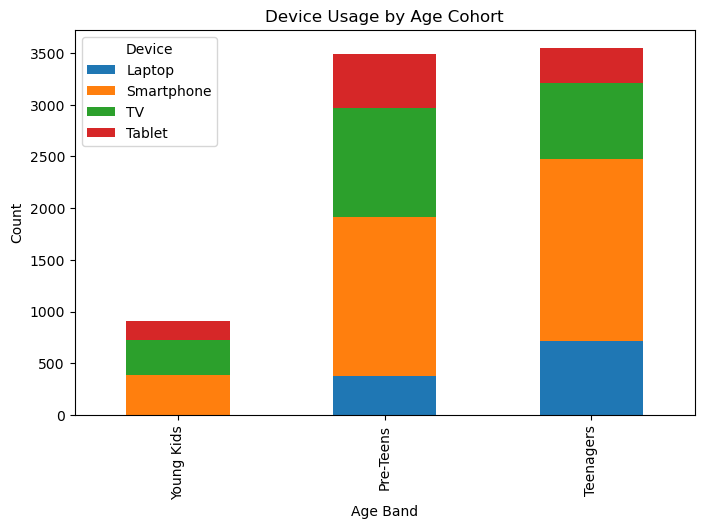

In [17]:
#Stacked Bar Chart: Age Band × Device
cohort_counts.plot(kind="bar", stacked=True, figsize=(8,5))

plt.title("Device Usage by Age Cohort")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.legend(title="Device")
plt.show()

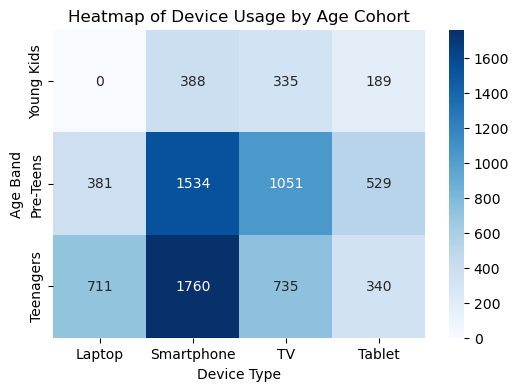

In [11]:
#Heatmap: Age Band × Device
plt.figure(figsize=(6,4))

sns.heatmap(cohort_counts, annot=True, cmap="Blues", fmt="d")

plt.title("Heatmap of Device Usage by Age Cohort")
plt.xlabel("Device Type")
plt.ylabel("Age Band")
plt.show()

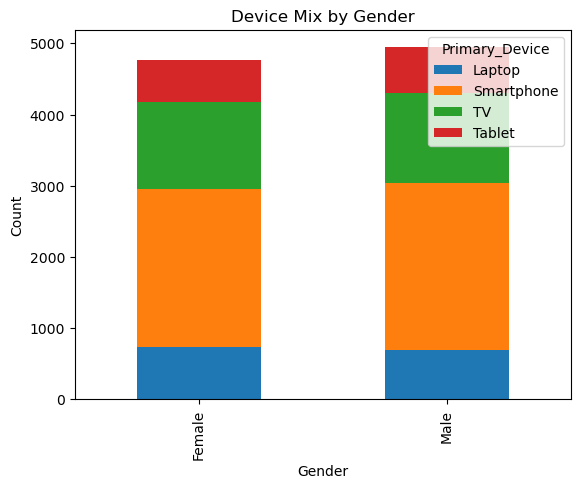

In [19]:
#Device Usage by Gender (Segment Comparison)
gender_device = pd.crosstab(data["Gender"], data["Primary_Device"])

gender_device.plot(kind="bar", stacked=True)

plt.title("Device Mix by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

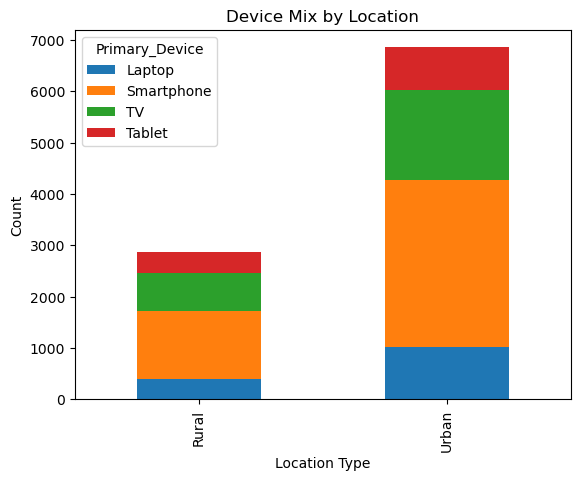

In [21]:
#Device Usage by Location (Urban/Rural Segment)
location_device = pd.crosstab(data["Urban_or_Rural"], data["Primary_Device"])

location_device.plot(kind="bar", stacked=True)

plt.title("Device Mix by Location")
plt.xlabel("Location Type")
plt.ylabel("Count")
plt.show()

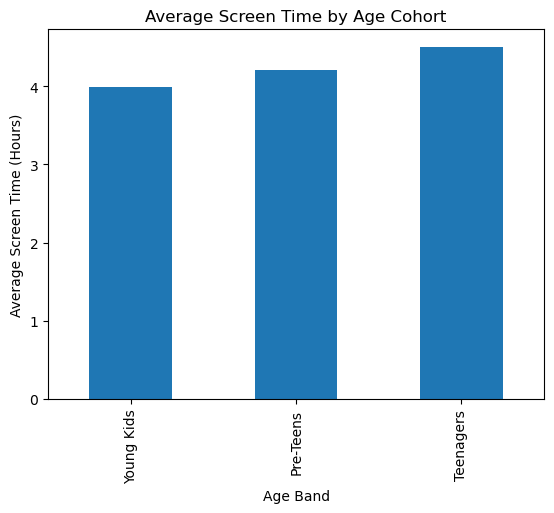

In [23]:
#Screen Time Cohorts (Age Band × Screen Time)
avg_screen = data.groupby("Age_Band", observed=False)["Avg_Daily_Screen_Time_hr"].mean()

avg_screen.plot(kind="bar")

plt.title("Average Screen Time by Age Cohort")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (Hours)")
plt.show()

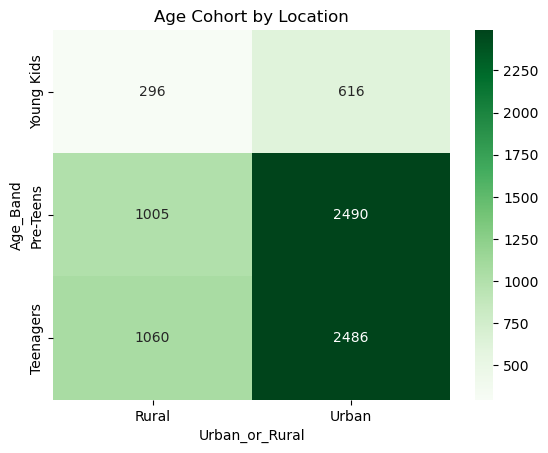

In [25]:
#Cohort Heatmap: Age Band × Location
cohort_location = pd.crosstab(data["Age_Band"], data["Urban_or_Rural"])

sns.heatmap(cohort_location, annot=True, cmap="Greens", fmt="d")

plt.title("Age Cohort by Location")
plt.show()